# 06. Recursive-Identification IRF and FEVD Analysis for Thailand Quarterly VAR

In the previous notebook, the quarterly reduced-form VAR for Thailand was estimated and checked as the baseline specification (lag = 1).
This notebook focuses on structural interpretation by identifying shocks through recursive Cholesky decomposition of that reduced-form VAR.

Main focus: trace how an oil-price shock propagates to GDP, CPI, interest rate, and exchange rate dynamics.

In [33]:
# Imports
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tools.sm_exceptions import ValueWarning
from statsmodels.tsa.api import VAR

# Hide non-critical statsmodels frequency warnings to keep outputs portable/clean.
warnings.filterwarnings('ignore', category=ValueWarning)

plt.rcParams['figure.dpi'] = 140
pd.set_option('display.max_columns', None)

## 1. Load Quarterly Modeling Dataset

In [42]:
from pathlib import Path

# Keep path handling simple and portable across common notebook working directories.
candidate_paths = [
    Path('data/processed/THA_model_ready_quarterly.csv'),
    Path('../../data/processed/THA_model_ready_quarterly.csv'),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        'Cannot find quarterly dataset. Tried:\n' + '\n'.join(str(p) for p in candidate_paths)
    )

df_model = pd.read_csv(data_path)

if 'date' in df_model.columns:
    df_model['date'] = pd.to_datetime(df_model['date'])
    df_model = df_model.set_index('date').sort_index()

print('Loaded from:', data_path)
print('Shape:', df_model.shape)
print('Head:')
print(df_model.head())
print('Current column order:')
print(df_model.columns.tolist())

Loaded from: ../../data/processed/THA_model_ready_quarterly.csv
Shape: (73, 5)
Head:
              ln_WTI     ln_GDP    ln_CPI  Interest     ln_FX
date                                                         
2006-03-31  4.147038  26.155337  4.508159  6.254871  3.627030
2006-06-30  4.254329  26.199388  4.513737  6.198061  3.604410
2006-09-30  4.252125  26.241580  4.519283  6.141251  3.581267
2006-12-31  4.093711  26.282063  4.524800  6.084442  3.557576
2007-03-31  4.060750  26.313068  4.533001  6.027845  3.538570
Current column order:
['ln_WTI', 'ln_GDP', 'ln_CPI', 'Interest', 'ln_FX']


## 2. Define Structural Variable Ordering

Cholesky-based orthogonalization requires an ordering assumption.

- Oil price (ln_WTI) is treated as the most exogenous variable in this small-open-economy setup.
- GDP (ln_GDP) responds with slower real-activity adjustment.
- CPI (ln_CPI) follows output dynamics and pricing pass-through.
- Interest rate (Interest) reflects policy reaction to macro conditions.
- Exchange rate (ln_FX) is placed last to capture the fastest financial-market adjustment.

In [35]:
ordering = [
    'ln_WTI',
    'ln_GDP',
    'ln_CPI',
    'Interest',
    'ln_FX'
]

print('Target ordering:')
print(ordering)

Target ordering:
['ln_WTI', 'ln_GDP', 'ln_CPI', 'Interest', 'ln_FX']


## 3. Reorder Dataset for Structural Identification

In [36]:
df_model = df_model[ordering]
print('Reordered columns:')
print(df_model.columns.tolist())

Reordered columns:
['ln_WTI', 'ln_GDP', 'ln_CPI', 'Interest', 'ln_FX']


## 4. Fit VAR with Fixed Lag from Previous Notebook

Lag selection is not repeated here. The selected lag from Notebook 05 is retained.

In [37]:
SELECTED_LAG = 1

model = VAR(df_model)
var_res = model.fit(SELECTED_LAG)

print('Selected lag (fixed from Notebook 05):', SELECTED_LAG)
print(var_res.summary())

Selected lag (fixed from Notebook 05): 1
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 01, Apr, 2026
Time:                     15:46:45
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -37.7900
Nobs:                     72.0000    HQIC:                  -38.3610
Log likelihood:           913.774    FPE:                1.50264e-17
AIC:                     -38.7387    Det(Omega_mle):     1.00704e-17
--------------------------------------------------------------------
Results for equation ln_WTI
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const              -1.808298         9.780190           -0.185           0.853
L1.ln_WTI           0.826893         0.078614           10.518           0.000
L1.ln_GDP           0.2695

## 5. Compute IRF (10-Quarter Horizon)

IRFs are computed over 10 quarters.
Orthogonalized responses are based on Cholesky decomposition under the ordering assumptions above.

In [38]:
irf = var_res.irf(10)

## 6. Plot Orthogonalized IRFs

All IRFs below are orthogonalized IRFs from the same recursive (Cholesky) identification.

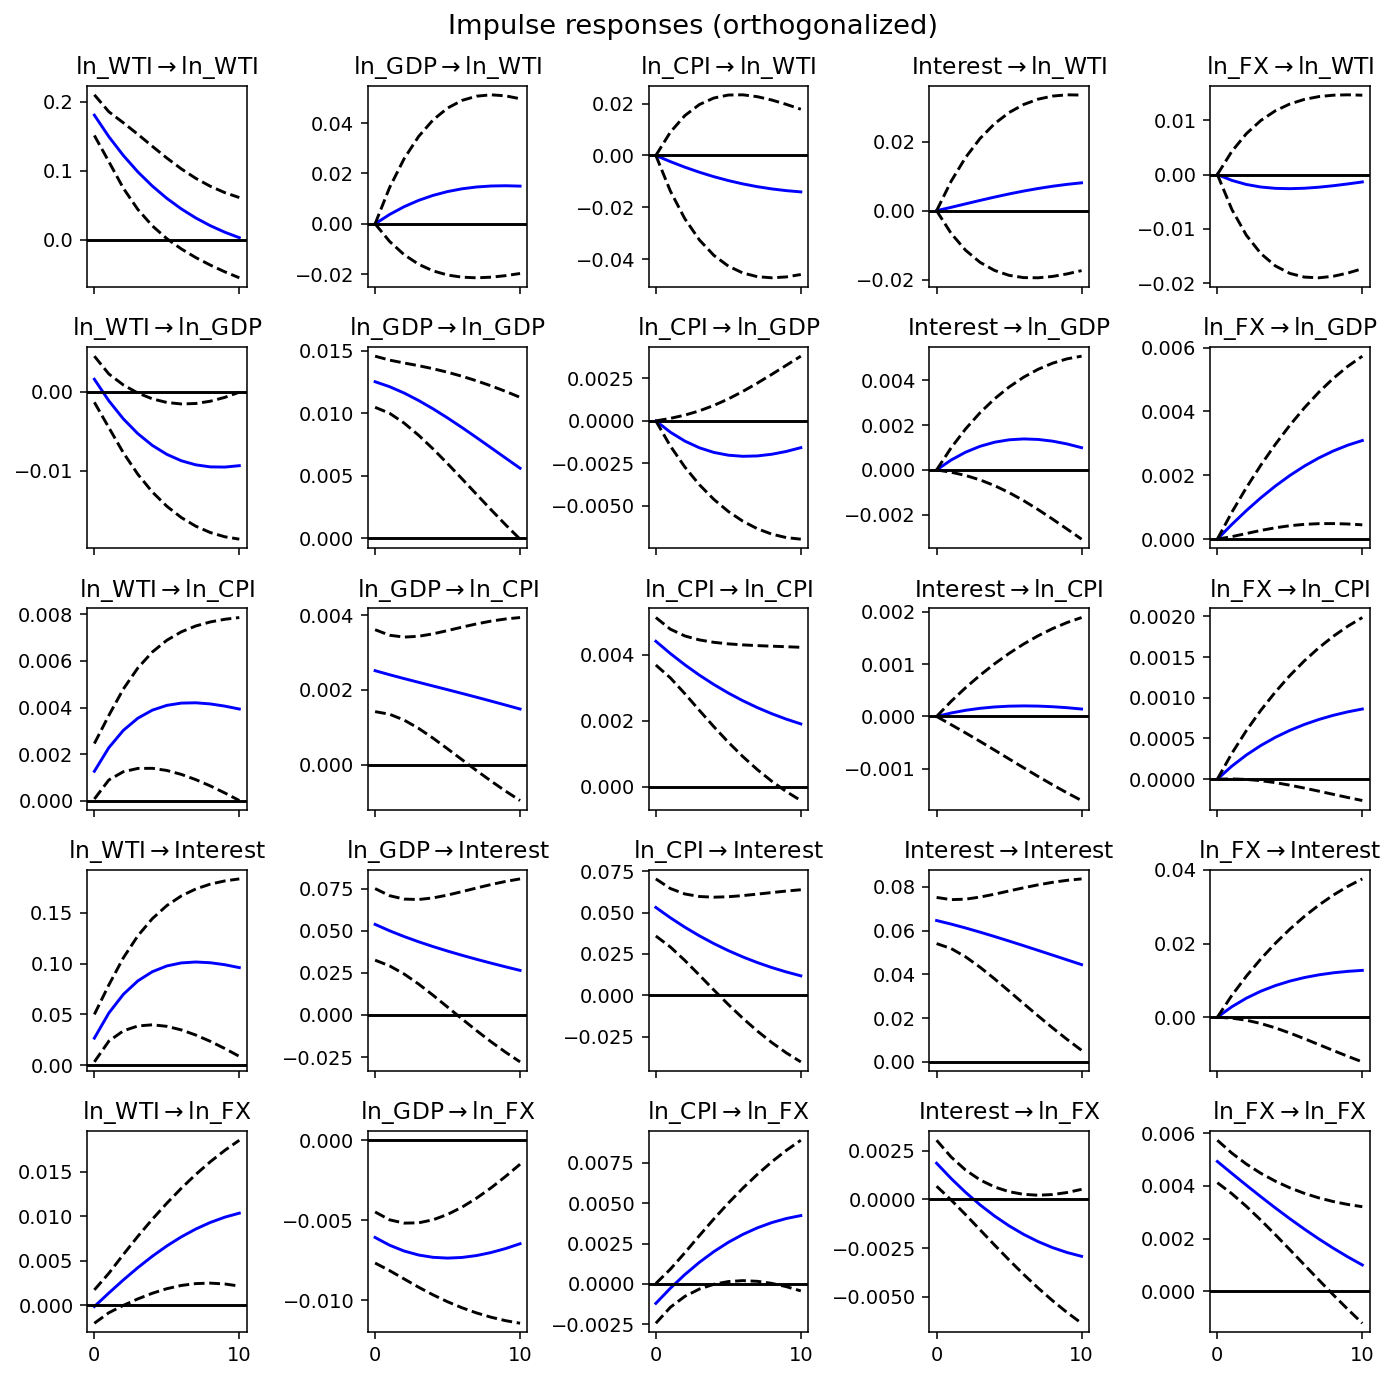

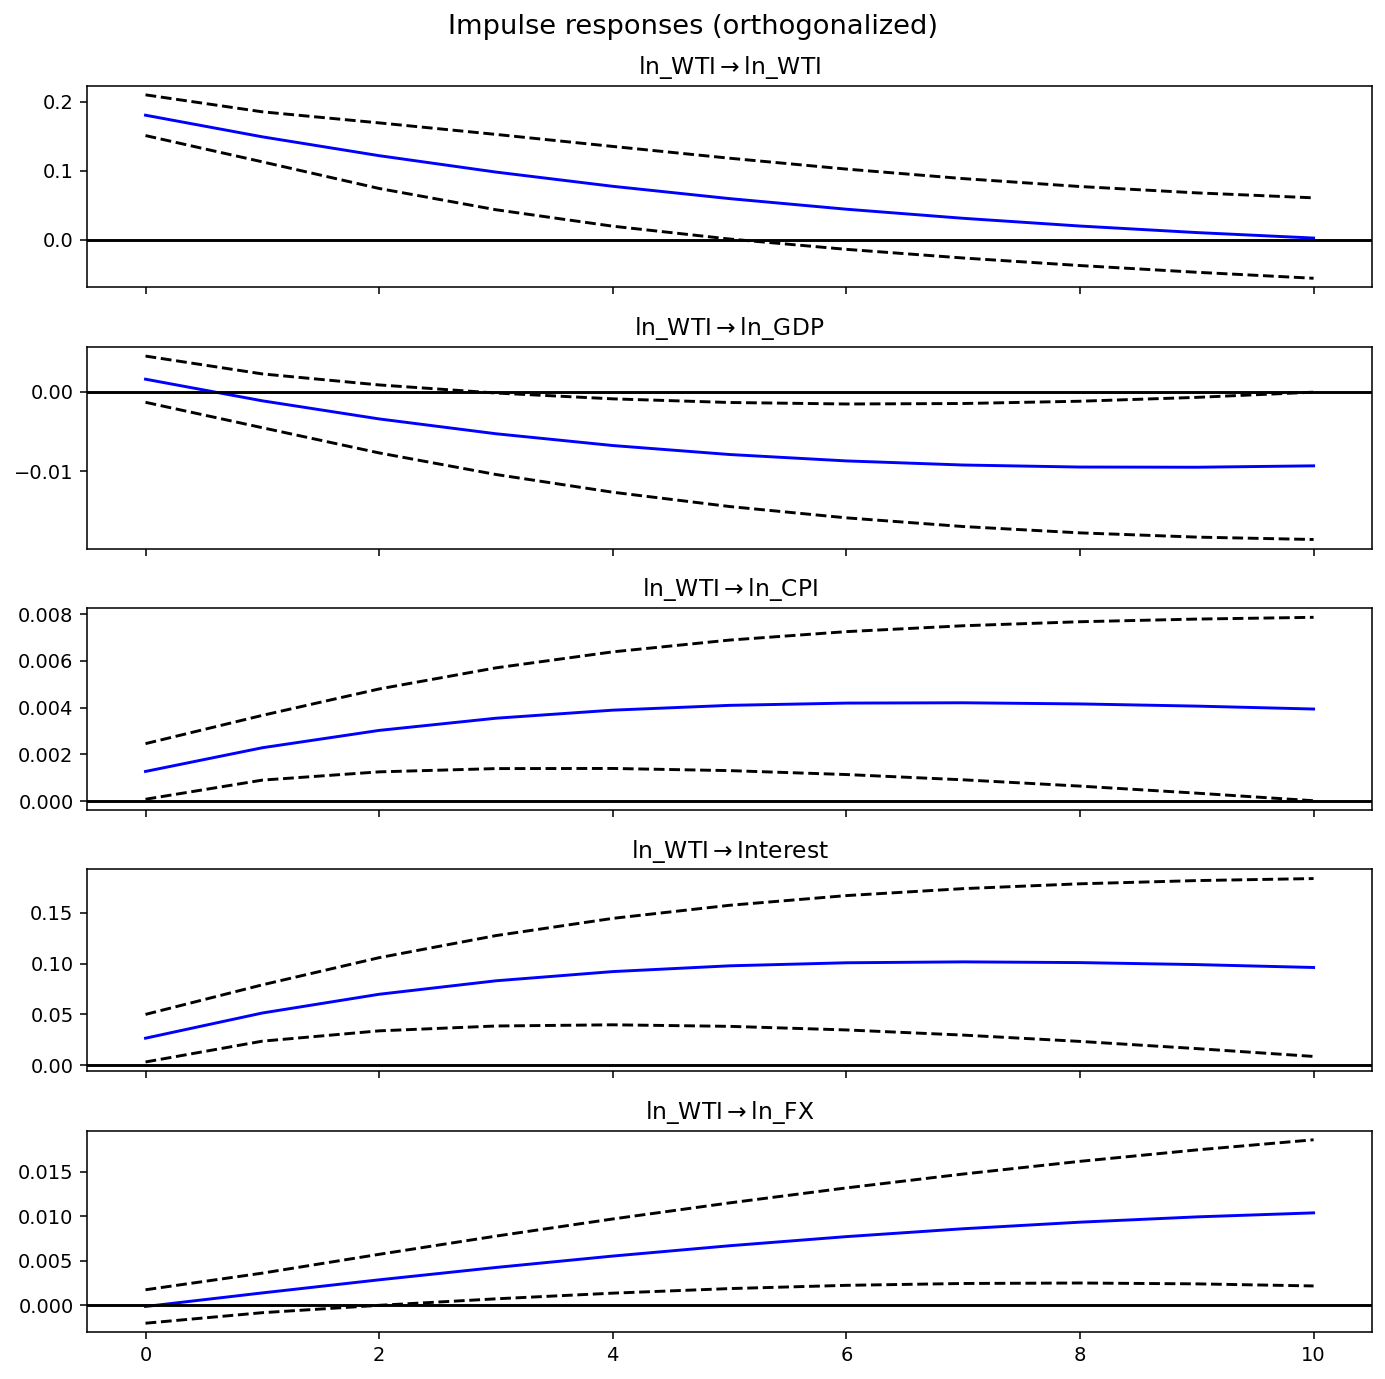

In [39]:
# Full orthogonalized IRF system
irf.plot(orth=True)
plt.tight_layout()
plt.show()

# Orthogonalized responses to oil-price shock only
irf.plot(orth=True, impulse='ln_WTI')
plt.tight_layout()
plt.show()

## 7. Forecast Error Variance Decomposition (FEVD)

FEVD is computed from the same recursively identified VAR.
It reports how much of each variable's forecast-error variance is attributable to each identified shock at different horizons.

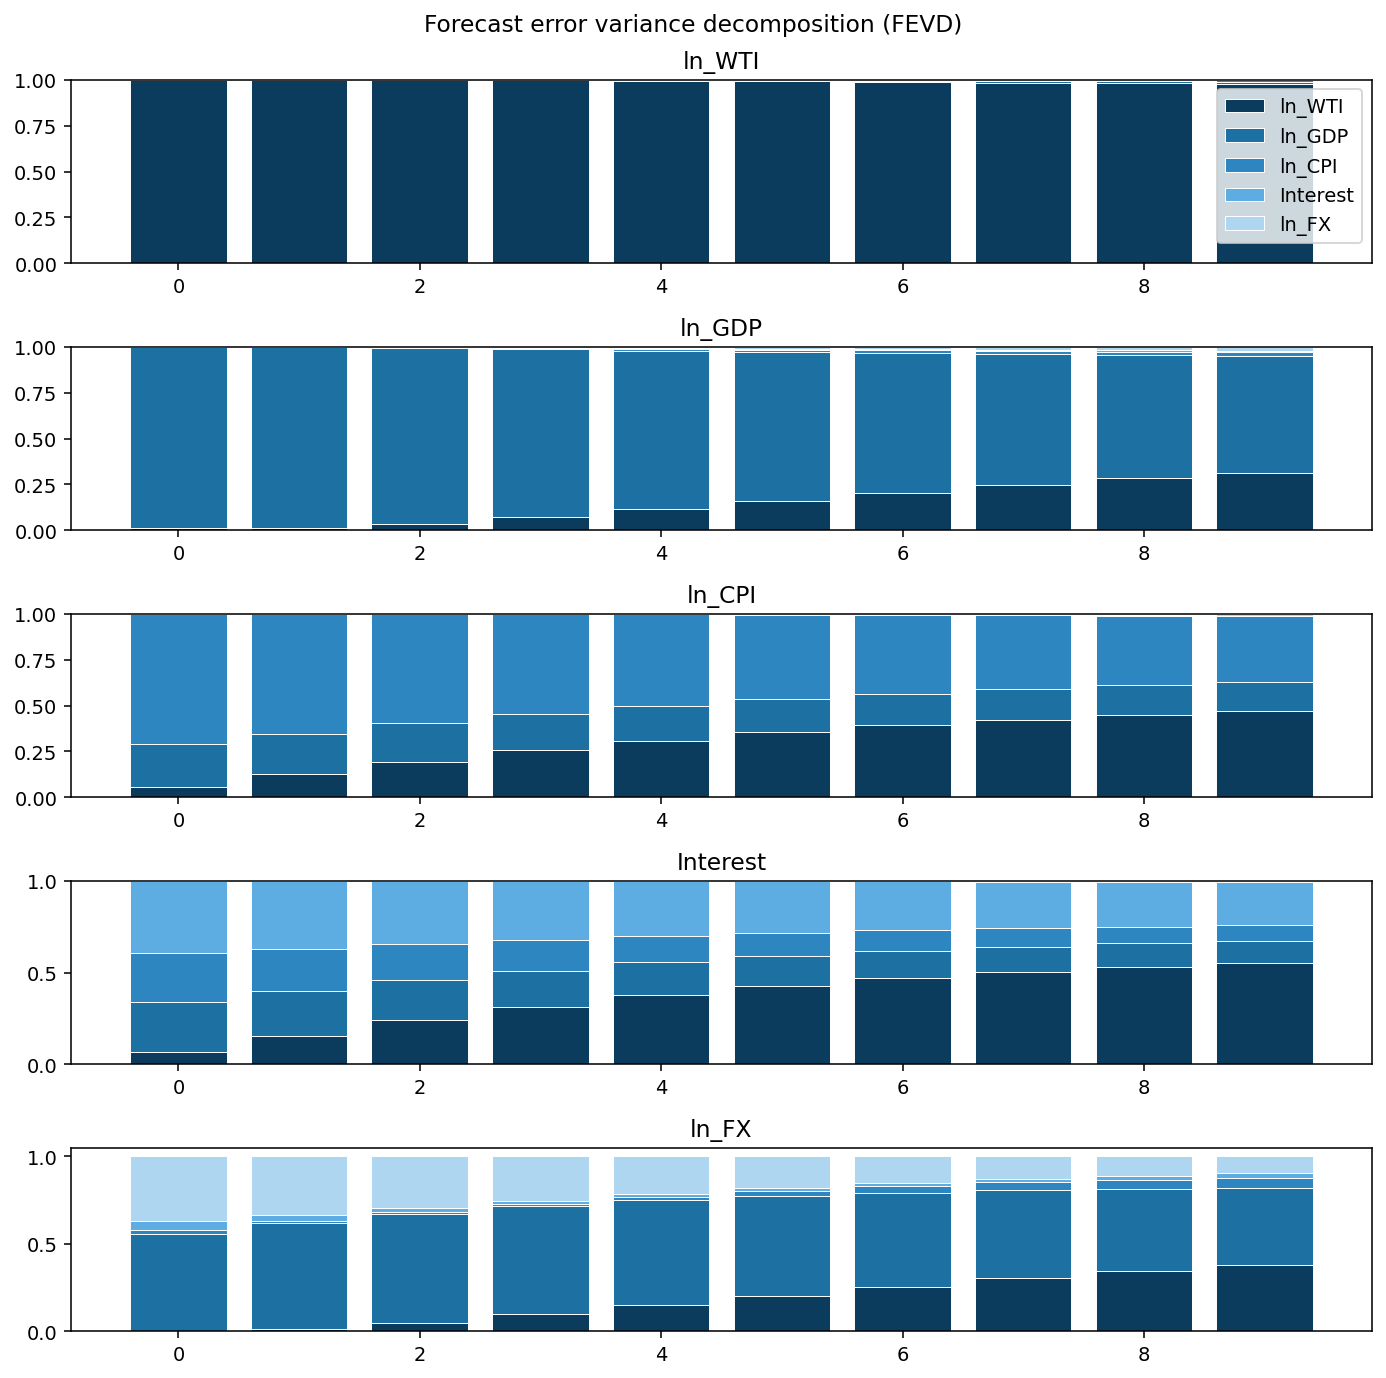

In [40]:
from matplotlib.patches import Patch

fevd = var_res.fevd(10)
fig = fevd.plot()

# FEVD is plotted as stacked bars, so recolor bar segments to a blue palette.
blue_palette = ['#0B3C5D', '#1D70A2', '#2E86C1', '#5DADE2', '#AED6F1']
for ax in fig.axes:
    for i, container in enumerate(ax.containers):
        color = blue_palette[i % len(blue_palette)]
        for patch in container.patches:
            patch.set_facecolor(color)
            patch.set_edgecolor('white')
            patch.set_linewidth(0.5)

# Remove all existing legends (axes-level and figure-level) to avoid duplicates.
for ax in fig.axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
for legend in list(fig.legends):
    legend.remove()

# Rebuild one clean legend with matching blue patches.
labels = ['ln_WTI', 'ln_GDP', 'ln_CPI', 'Interest', 'ln_FX']
legend_handles = [
    Patch(facecolor=blue_palette[i], edgecolor='white', linewidth=0.5, label=labels[i])
    for i in range(len(labels))
]
fig.axes[0].legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.show()

In [41]:
# Compact diagnostics to support interpretation (orthogonalized oil-shock responses)
lower, upper = irf.errband_mc(orth=True, repl=1000, signif=0.05, seed=42)
imp_idx = ordering.index('ln_WTI')

print('Orthogonalized IRF sign by horizon (h=1..10) and 95% band includes zero:')
for var in ['ln_GDP', 'ln_CPI', 'Interest', 'ln_FX']:
    j = ordering.index(var)
    signs = ['+' if irf.orth_irfs[h, j, imp_idx] > 0 else '-' if irf.orth_irfs[h, j, imp_idx] < 0 else '0' for h in range(1, 11)]
    zero_in_band = [bool(lower[h, j, imp_idx] <= 0 <= upper[h, j, imp_idx]) for h in range(1, 11)]
    print(f'{var}: signs={"".join(signs)}, band_contains_zero={zero_in_band}')

fevd_oil = var_res.fevd(10)
print('\nFEVD oil-shock share at horizons h=1,4,8,10:')
for var in ['ln_GDP', 'ln_CPI', 'Interest', 'ln_FX']:
    j = ordering.index(var)
    shares = fevd_oil.decomp[j, :, imp_idx]
    print(var, {1: round(float(shares[0]), 4), 4: round(float(shares[3]), 4), 8: round(float(shares[7]), 4), 10: round(float(shares[9]), 4)})

Orthogonalized IRF sign by horizon (h=1..10) and 95% band includes zero:
ln_GDP: signs=----------, band_contains_zero=[False, False, False, False, False, False, False, False, False, False]
ln_CPI: signs=++++++++++, band_contains_zero=[False, False, False, False, False, False, False, False, False, False]
Interest: signs=++++++++++, band_contains_zero=[False, False, False, False, False, False, False, False, False, False]
ln_FX: signs=++++++++++, band_contains_zero=[False, False, False, False, False, False, False, False, False, False]

FEVD oil-shock share at horizons h=1,4,8,10:
ln_GDP {1: 0.0153, 4: 0.0711, 8: 0.2469, 10: 0.3146}
ln_CPI {1: 0.059, 4: 0.2554, 8: 0.4233, 10: 0.4696}
Interest {1: 0.067, 4: 0.3147, 8: 0.5022, 10: 0.5499}
ln_FX {1: 0.0003, 4: 0.0968, 8: 0.3026, 10: 0.3799}


## 8. Interpretation of Orthogonalized Oil-Shock Responses

Based on the orthogonalized IRFs (recursive Cholesky identification):

- GDP (ln_GDP): after a small near-impact movement, the response turns negative and remains below zero through most horizons, consistent with a contractionary output effect of oil shocks.
- CPI (ln_CPI): the response is positive across horizons, consistent with inflationary pass-through from higher oil prices.
- Interest: the response is positive and relatively strong, suggesting a policy-rate reaction to inflation/output pressures in the system.
- Exchange rate (ln_FX): after a very small initial movement, the response becomes positive and persistent, indicating depreciation pressure in this specification.

In this run, the 95% Monte Carlo bands from orthogonalized IRFs are mostly away from zero over h=1..10 for these responses. Even so, interpretation should remain cautious because uncertainty intervals, sample size, and identifying assumptions can affect inference.

## 9. Limitations

- Recursive identification is ordering-dependent; changing the variable order can change IRFs and FEVD shares.
- Residual diagnostics from the previous notebook were not fully perfect, so structural interpretation should remain cautious.
- Stability was checked in the previous notebook for the same lag specification; interpretation here is conditional on that baseline remaining appropriate.

## 10. Interpretation of Thailand Results

The Thailand results provide more than just the expected directional signs of macroeconomic responses. They also reveal the timing, persistence, and relative importance of oil-price shocks across key macroeconomic variables.

### 1. Magnitude and Relative Importance

The evidence suggests that oil shocks matter for all four macroeconomic variables in the system, but their importance is not uniform. Based on the FEVD results, the contribution of oil shocks rises steadily over the forecast horizon and becomes especially important for interest rates and inflation. By horizon 10, oil shocks account for approximately 55% of the forecast error variance of interest rates, 47% for CPI, 38% for the exchange rate, and 31% for GDP. This indicates that the Thai economy appears to absorb oil-price disturbances more strongly through the inflation and monetary-policy channels than through output alone.

### 2. Timing of Responses

The responses do not emerge in exactly the same way across variables. Inflation and interest rates begin to show economically meaningful responses relatively early and remain important over time. By contrast, the exchange-rate channel appears more delayed: the role of oil shocks in explaining exchange-rate variation is limited at very short horizons but increases substantially at medium horizons. This pattern suggests that the transmission of oil shocks to Thailand’s external sector may operate more gradually than the transmission to prices and monetary conditions.

### 3. Persistence of Effects

The impulse responses indicate that the effects of a positive oil-price shock are persistent rather than purely transitory. GDP remains below zero throughout the forecast horizon, while CPI, interest rates, and the exchange rate remain above zero over the same period. This implies that the macroeconomic consequences of oil shocks are not confined to the immediate aftermath of the shock, but instead continue to shape Thailand’s adjustment path for several quarters.

### 4. Economic Interpretation

Taken together, the results imply that Thailand responds to oil-price shocks through a sustained inflation–interest-rate–exchange-rate adjustment process. Higher oil prices appear to increase domestic price pressures, which is followed by a stronger interest-rate response and increasing pressure on the exchange rate. Although output also declines after the shock, the output channel appears less dominant than the price and policy channels. For an oil-importing economy such as Thailand, this pattern is economically plausible: oil-price increases raise production and transportation costs, feed into inflation, and trigger broader macroeconomic adjustment over time.

### Overall Insight

Overall, the Thailand evidence suggests that the main empirical value of the model lies not simply in confirming that oil shocks are inflationary and contractionary, but in showing that these effects are persistent, that their importance grows with the forecast horizon, and that the strongest transmission appears to occur through inflation and monetary-policy adjustment rather than output alone.

## 11. Final Conclusion

This quarterly analysis for Thailand suggests that oil price shocks have meaningful macroeconomic effects within a recursively identified VAR framework. A positive shock to oil prices is associated with a decline in real output, an increase in consumer prices, a rise in interest rates, and upward pressure on the exchange rate. In economic terms, the results indicate that higher oil prices are contractionary for GDP, inflationary for CPI, and are linked to tighter monetary conditions as well as depreciation pressure on the domestic currency.

The impulse response functions show that these effects are not purely short-lived. Instead, several responses persist over multiple quarters, especially for CPI, interest rates, and the exchange rate. Among the variables in the system, interest rates appear to exhibit one of the strongest and most sustained responses, which may reflect monetary-policy adjustment to inflationary pressures following an oil shock. GDP responds negatively, although the magnitude and precision of the response vary across forecast horizons.

The FEVD results further support the importance of oil shocks in Thailand’s macroeconomic dynamics. While each variable is initially influenced largely by its own innovations, the contribution of oil price shocks tends to increase over longer forecast horizons, particularly for inflation, interest rates, and exchange rate movements. This suggests that oil market disturbances become a more relevant source of medium-run macroeconomic fluctuations over time.

Overall, the findings are broadly consistent with economic intuition for an oil-importing economy such as Thailand: higher oil prices raise production and transportation costs, feed into inflation, trigger policy tightening, and place pressure on external adjustment. However, these results should still be interpreted with caution because recursive identification depends on the chosen variable ordering, and the estimated responses may remain sensitive to sample size and model specification.